# CUDA memory profiling: Neural OT rearrangement on the sinusoidal target

This notebook is a small, instrumented version of the Figure 1 sinusoidal rearrangement experiment. It profiles CUDA memory by section, exports a PyTorch profiler trace, and prints a concise summary of the largest memory allocations. It is intentionally configured with small data and networks so it can be run repeatedly while profiling.

The original plotting behavior is preserved in a lightweight form at the end. Set `CUDA_PROFILING_ENABLED = False` to run the notebook without CUDA-memory instrumentation.


In [1]:
from __future__ import annotations

from contextlib import contextmanager
from pathlib import Path
import gc
import math
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.stats import chi2
from torch.profiler import ProfilerActivity, profile, record_function

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    candidates = [Path.cwd().parent, Path.cwd().parent.parent]
    repo_root = next((candidate for candidate in candidates if (candidate / "src").exists()), repo_root)

src_path = str(repo_root / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from configs.datasets.synthetic import SinusoidalTransportDatasetConfig
from configs.predictors.rearranged_transport import RearrangedTransportPredictorConfig
from configs.predictors.transport import NeuralOptimalTransportPredictorConfig
from data.datasets.synthetic import SinusoidalTransportDataset
from data.loaders import make_xy_dataloader
from predictors.rearranged_transport import RearrangedTransportPredictor
from predictors.transport import NeuralOptimalTransportPredictor

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


## Profiling controls

The dataset is kept on CPU by default so the notebook can explicitly measure transfer to CUDA. The model device becomes CUDA when available. `DETAILED_MEMORY_HISTORY_ENABLED` is disabled by default because allocator snapshots add noticeable overhead.


In [2]:
seed = 7
torch.manual_seed(seed)
np.random.seed(seed)

CUDA_PROFILING_ENABLED = True
DETAILED_MEMORY_HISTORY_ENABLED = False
RUN_TORCH_PROFILER = True
RUN_MEMORY_GROWTH_CHECK = True
DIAGNOSTIC_EMPTY_CACHE_ENABLED = False

CUDA_AVAILABLE = torch.cuda.is_available()
PROFILE_CUDA = CUDA_PROFILING_ENABLED and CUDA_AVAILABLE
model_device = "cuda" if CUDA_AVAILABLE else "cpu"
dataset_device = "cpu"
dtype = "float32"
torch_dtype = getattr(torch, dtype)

# Small defaults for profiling. Increase these on the CUDA machine once the
# profiler is working.
n_train = 512
n_calibration = 128
n_test = 128
batch_size = 64
profile_batch_size = 64

coverage_mass = 0.95
x_plot_value = 0.0
mc_samples_per_x = 1

neural_ot_hidden_dim = 32
neural_ot_hidden_layers = 2
c_transform_max_iter = 20
neural_ot_warmup_steps = 1
neural_ot_profile_warmup_steps = 1

rearrangement_hidden_dim = 16
rearrangement_hidden_layers = 2
rearrangement_ode_steps = 4
rearrangement_profile_warmup_steps = 1
REARRANGEMENT_VECTOR_FIELD_IMPLEMENTATION = "standard"  # Use "experimental" to profile the JVP implementation.

memory_growth_check_steps = 3
n_boundary_points = 128
plot_batch_size = 128

notebook_dir = repo_root / "notebooks" / "profiling"
profiling_output_dir = notebook_dir / "profiling_outputs"
profiling_output_dir.mkdir(parents=True, exist_ok=True)
trace_path = profiling_output_dir / "figure_1_neural_ot_rearranged_sinusoidal_cuda_trace.json"
memory_snapshot_path = profiling_output_dir / "figure_1_neural_ot_rearranged_sinusoidal_cuda_memory_snapshot.pickle"
output_path = profiling_output_dir / "figure_1_neural_ot_rearranged_sinusoidal_profiled.pdf"

print(f"CUDA available: {CUDA_AVAILABLE}")
print(f"model_device: {model_device}")
print(f"dataset_device: {dataset_device}")
print(f"profiling_output_dir: {profiling_output_dir}")


CUDA available: False
model_device: cpu
dataset_device: cpu
profiling_output_dir: /Users/vladimir.kondratyev/minimal_volume_conformal_prediction/notebooks/profiling/profiling_outputs


## CUDA memory helpers

Each measured section records current allocated/reserved memory, peak allocated/reserved memory, persistent allocated-memory delta, and temporary peak allocated-memory delta. CUDA synchronization is called before reading allocator statistics.


In [3]:
PROFILING_RECORDS: list[dict[str, float | str | None]] = []
PROFILER_RESULT = None
PROFILER_TOP_CUDA_MEMORY_OPS: list[tuple[str, float]] = []
PROFILER_TOP_CUDA_TIME_OPS: list[tuple[str, float]] = []
MEMORY_GROWTH_ALLOCATED_MIB: list[float] = []
RETENTION_NOTES: list[str] = []


def _format_bytes(num_bytes: int | float | None) -> str:
    if num_bytes is None:
        return "n/a"
    value = float(num_bytes)
    mib = value / 1024**2
    if mib >= 1024:
        return f"{mib / 1024:.2f} GiB"
    return f"{mib:.2f} MiB"


def _cuda_sync() -> None:
    if CUDA_AVAILABLE:
        torch.cuda.synchronize()


def cuda_memory_stats() -> dict[str, int | None]:
    if not PROFILE_CUDA:
        return {
            "allocated": None,
            "reserved": None,
            "peak_allocated": None,
            "peak_reserved": None,
        }

    _cuda_sync()
    return {
        "allocated": torch.cuda.memory_allocated(),
        "reserved": torch.cuda.memory_reserved(),
        "peak_allocated": torch.cuda.max_memory_allocated(),
        "peak_reserved": torch.cuda.max_memory_reserved(),
    }


def report_cuda_memory(label: str) -> dict[str, int | None]:
    stats = cuda_memory_stats()
    print(
        f"[cuda-memory] {label}: "
        f"allocated={_format_bytes(stats['allocated'])}, "
        f"reserved={_format_bytes(stats['reserved'])}, "
        f"peak_allocated={_format_bytes(stats['peak_allocated'])}, "
        f"peak_reserved={_format_bytes(stats['peak_reserved'])}"
    )
    return stats


@contextmanager
def cuda_memory_section(label: str):
    gc.collect()
    if PROFILE_CUDA:
        _cuda_sync()
        before_allocated = torch.cuda.memory_allocated()
        before_reserved = torch.cuda.memory_reserved()
        torch.cuda.reset_peak_memory_stats()
    else:
        before_allocated = None
        before_reserved = None

    start = time.perf_counter()
    print(f"\n--- {label} ---")
    report_cuda_memory(f"before {label}")

    try:
        yield
    finally:
        elapsed = time.perf_counter() - start
        if PROFILE_CUDA:
            _cuda_sync()
            after_allocated = torch.cuda.memory_allocated()
            after_reserved = torch.cuda.memory_reserved()
            peak_allocated = torch.cuda.max_memory_allocated()
            peak_reserved = torch.cuda.max_memory_reserved()
            persistent_delta = after_allocated - before_allocated
            temporary_peak_delta = peak_allocated - before_allocated
        else:
            after_allocated = None
            after_reserved = None
            peak_allocated = None
            peak_reserved = None
            persistent_delta = None
            temporary_peak_delta = None

        print(
            f"[cuda-memory] after {label}: "
            f"allocated={_format_bytes(after_allocated)}, "
            f"reserved={_format_bytes(after_reserved)}, "
            f"peak_allocated={_format_bytes(peak_allocated)}, "
            f"peak_reserved={_format_bytes(peak_reserved)}, "
            f"persistent_delta={_format_bytes(persistent_delta)}, "
            f"temporary_peak_delta={_format_bytes(temporary_peak_delta)}, "
            f"elapsed={elapsed:.3f}s"
        )
        PROFILING_RECORDS.append({
            "label": label,
            "allocated_mib": None if after_allocated is None else after_allocated / 1024**2,
            "reserved_mib": None if after_reserved is None else after_reserved / 1024**2,
            "peak_allocated_mib": None if peak_allocated is None else peak_allocated / 1024**2,
            "peak_reserved_mib": None if peak_reserved is None else peak_reserved / 1024**2,
            "persistent_delta_mib": None if persistent_delta is None else persistent_delta / 1024**2,
            "temporary_peak_delta_mib": None if temporary_peak_delta is None else temporary_peak_delta / 1024**2,
            "elapsed_seconds": elapsed,
        })


def start_detailed_memory_history() -> None:
    if not (PROFILE_CUDA and DETAILED_MEMORY_HISTORY_ENABLED):
        return
    try:
        torch.cuda.memory._record_memory_history(max_entries=100_000)
        print(f"Detailed CUDA memory history enabled; snapshot will be saved to {memory_snapshot_path}")
    except Exception as exc:
        print(f"Could not enable detailed CUDA memory history: {exc}")


def stop_and_dump_detailed_memory_history() -> None:
    if not (PROFILE_CUDA and DETAILED_MEMORY_HISTORY_ENABLED):
        return
    try:
        torch.cuda.memory._dump_snapshot(str(memory_snapshot_path))
        torch.cuda.memory._record_memory_history(enabled=None)
        print(f"Saved CUDA memory snapshot to {memory_snapshot_path}")
    except Exception as exc:
        print(f"Could not dump detailed CUDA memory history: {exc}")


def diagnostic_empty_cache(label: str = "diagnostic_empty_cache") -> None:
    if not (PROFILE_CUDA and DIAGNOSTIC_EMPTY_CACHE_ENABLED):
        return
    print("Diagnostic only: calling torch.cuda.empty_cache(); this does not fix live tensor retention.")
    report_cuda_memory(f"before {label}")
    torch.cuda.empty_cache()
    report_cuda_memory(f"after {label}")


report_cuda_memory("initial state")


[cuda-memory] initial state: allocated=n/a, reserved=n/a, peak_allocated=n/a, peak_reserved=n/a


{'allocated': None,
 'reserved': None,
 'peak_allocated': None,
 'peak_reserved': None}

## Dataset and explicit CUDA transfer

The dataset stays on CPU. The section named `data_transfer_to_model_device` measures the representative batch transfer to CUDA when CUDA is available.


In [4]:
with cuda_memory_section("dataset_initialization_cpu"):
    dataset_config = SinusoidalTransportDatasetConfig(
        n_train=n_train,
        n_calibration=n_calibration,
        n_test=n_test,
        x_dim=1,
        y_dim=2,
        seed=seed,
        device=dataset_device,
        dtype=dtype,
    )
    dataset = SinusoidalTransportDataset(dataset_config)
    splits = dataset.get_splits()
    train_dataloader = make_xy_dataloader(
        data=splits.train,
        batch_size=batch_size,
        shuffle=True,
        drop_last=True,
        pin_memory=CUDA_AVAILABLE,
    )

batch_iter = iter(train_dataloader)
profile_batch_cpu = next(batch_iter)

with cuda_memory_section("data_transfer_to_model_device"):
    profile_batch = tuple(
        tensor.to(device=model_device, dtype=torch_dtype, non_blocking=CUDA_AVAILABLE)
        for tensor in profile_batch_cpu
    )

print("train x/y:", splits.train.x.shape, splits.train.y.shape, splits.train.x.device, splits.train.y.device)
print("profile batch x/y:", profile_batch[0].shape, profile_batch[1].shape, profile_batch[0].device, profile_batch[1].device)



--- dataset_initialization_cpu ---
[cuda-memory] before dataset_initialization_cpu: allocated=n/a, reserved=n/a, peak_allocated=n/a, peak_reserved=n/a
[cuda-memory] after dataset_initialization_cpu: allocated=n/a, reserved=n/a, peak_allocated=n/a, peak_reserved=n/a, persistent_delta=n/a, temporary_peak_delta=n/a, elapsed=0.002s

--- data_transfer_to_model_device ---
[cuda-memory] before data_transfer_to_model_device: allocated=n/a, reserved=n/a, peak_allocated=n/a, peak_reserved=n/a
[cuda-memory] after data_transfer_to_model_device: allocated=n/a, reserved=n/a, peak_allocated=n/a, peak_reserved=n/a, persistent_delta=n/a, temporary_peak_delta=n/a, elapsed=0.000s
train x/y: torch.Size([512, 1]) torch.Size([512, 2]) cpu cpu
profile batch x/y: torch.Size([64, 1]) torch.Size([64, 2]) cpu cpu


## Representative training-step functions

These functions avoid storing graph-attached tensors in Python lists and use `optimizer.zero_grad(set_to_none=True)`. Record-function regions make the profiler table easier to interpret.


In [5]:
def batch_to_device(batch):
    return tuple(
        tensor.to(device=model_device, dtype=torch_dtype, non_blocking=CUDA_AVAILABLE)
        for tensor in batch
    )


def sample_uniform_ball(batch_size: int, dimension: int, radius: float) -> torch.Tensor:
    direction = torch.randn(batch_size, dimension, device=model_device, dtype=torch_dtype)
    direction = direction / direction.norm(dim=-1, keepdim=True).clamp_min(torch.finfo(torch_dtype).eps)
    radial = torch.rand(batch_size, 1, device=model_device, dtype=torch_dtype).pow(1.0 / dimension)
    return radius * radial * direction


def run_neural_ot_training_step(predictor, optimizer, batch) -> float:
    predictor.potential_network.train()
    x_batch, y_batch = batch_to_device(batch)

    with record_function("forward"):
        y_scaled = predictor.scale_y(y_batch)
        u = torch.randn_like(y_scaled)
        with record_function("c_transform_inverse"):
            inverse = predictor.c_transform_inverse(x=x_batch, point=y_scaled)
        with record_function("loss"):
            psi = predictor.estimate_psi(x=x_batch, y_scaled=y_scaled, u=inverse)
            phi = predictor.estimate_phi(x=x_batch, u=u)
            loss = phi.mean() + psi.mean()

    optimizer.zero_grad(set_to_none=True)
    with record_function("backward"):
        loss.backward()
    with record_function("optimizer_step"):
        torch.nn.utils.clip_grad_norm_(predictor.potential_network.parameters(), max_norm=1.0)
        optimizer.step()

    return float(loss.detach().cpu())


def run_rearranged_training_step(
    rearranged_predictor,
    optimizer,
    batch,
    *,
    include_standalone_autodiff_probe: bool = False,
) -> float:
    rearranged_predictor.transport_predictor.eval()
    rearranged_predictor.rearrangement_flow.train()

    x_batch, _ = batch_to_device(batch)
    x = x_batch.repeat_interleave(mc_samples_per_x, dim=0)
    radius = float(np.sqrt(chi2.ppf(coverage_mass, df=rearranged_predictor.y_dim)))
    u = sample_uniform_ball(
        batch_size=x.shape[0],
        dimension=rearranged_predictor.y_dim,
        radius=radius,
    )

    if include_standalone_autodiff_probe:
        # This names the exact Jacobian/JVP-heavy vector-field computation. The
        # same computation is also called repeatedly inside ODE integration.
        with record_function("jacobian_computation"):
            t = torch.full((x.shape[0], 1), 0.5, device=model_device, dtype=torch_dtype)
            probe_velocity = rearranged_predictor.rearrangement_flow.vector_field(u=u, x=x, t=t)
        del probe_velocity

    with record_function("forward"):
        with record_function("ode_integration"):
            rearranged_u = rearranged_predictor.rearrangement_pushforward(x=x, u=u)
        with record_function("hessian_computation"):
            transport_log_det = rearranged_predictor.transport_log_det(x=x, u=rearranged_u)
        with record_function("loss"):
            rearrangement_log_det = rearranged_predictor._rearrangement_log_det_from_pushforward(
                u=rearranged_predictor.to_device(u),
                rearranged_u=rearranged_u,
            )
            weights = transport_log_det + rearrangement_log_det
            loss = torch.logsumexp(weights, dim=0) - math.log(weights.numel())

    optimizer.zero_grad(set_to_none=True)
    with record_function("backward"):
        loss.backward()
    with record_function("optimizer_step"):
        torch.nn.utils.clip_grad_norm_(rearranged_predictor.rearrangement_flow.parameters(), max_norm=1.0)
        optimizer.step()

    return float(loss.detach().cpu())


def run_sampling_step(model, n_samples: int = 128) -> torch.Tensor:
    model.eval()
    with torch.no_grad(), record_function("sampling"):
        x = torch.full((n_samples, dataset.x_dim), x_plot_value, device=model_device, dtype=torch_dtype)
        u = torch.randn(n_samples, dataset.y_dim, device=model_device, dtype=torch_dtype)
        y = model.pushforward(x=x, u=u)
    return y.detach()


## Model initialization and warm-up

The warm-up sections run a small number of representative iterations before profiling so one-time allocations are separated from the profiled step.


In [6]:
with cuda_memory_section("neural_ot_model_initialization"):
    predictor_config = NeuralOptimalTransportPredictorConfig(
        x_dim=dataset.x_dim,
        y_dim=dataset.y_dim,
        hidden_dim=neural_ot_hidden_dim,
        num_hidden_layers=neural_ot_hidden_layers,
        c_transform_lr=0.5,
        c_transform_max_iter=c_transform_max_iter,
        seed=seed,
        device=model_device,
        dtype=dtype,
    )
    predictor = NeuralOptimalTransportPredictor(predictor_config)
    neural_ot_optimizer = torch.optim.AdamW(
        predictor.potential_network.parameters(),
        lr=1e-3,
        weight_decay=1e-4,
    )

with cuda_memory_section("neural_ot_y_scaler_warmup"):
    predictor.warmup_y_scaler(train_dataloader)
    predictor.y_scaler.eval()

with cuda_memory_section("neural_ot_training_warmup"):
    for step in range(neural_ot_profile_warmup_steps):
        loss_value = run_neural_ot_training_step(predictor, neural_ot_optimizer, profile_batch_cpu)
        print(f"warmup neural OT step {step + 1}: loss={loss_value:.4f}")

with cuda_memory_section("neural_ot_representative_training_step"):
    neural_ot_loss_value = run_neural_ot_training_step(predictor, neural_ot_optimizer, profile_batch_cpu)
    print(f"profiled neural OT loss={neural_ot_loss_value:.4f}")

predictor.eval()
report_cuda_memory("after neural OT setup")



--- neural_ot_model_initialization ---
[cuda-memory] before neural_ot_model_initialization: allocated=n/a, reserved=n/a, peak_allocated=n/a, peak_reserved=n/a


[cuda-memory] after neural_ot_model_initialization: allocated=n/a, reserved=n/a, peak_allocated=n/a, peak_reserved=n/a, persistent_delta=n/a, temporary_peak_delta=n/a, elapsed=1.112s

--- neural_ot_y_scaler_warmup ---
[cuda-memory] before neural_ot_y_scaler_warmup: allocated=n/a, reserved=n/a, peak_allocated=n/a, peak_reserved=n/a
[cuda-memory] after neural_ot_y_scaler_warmup: allocated=n/a, reserved=n/a, peak_allocated=n/a, peak_reserved=n/a, persistent_delta=n/a, temporary_peak_delta=n/a, elapsed=0.009s

--- neural_ot_training_warmup ---
[cuda-memory] before neural_ot_training_warmup: allocated=n/a, reserved=n/a, peak_allocated=n/a, peak_reserved=n/a
warmup neural OT step 1: loss=4.3043
[cuda-memory] after neural_ot_training_warmup: allocated=n/a, reserved=n/a, peak_allocated=n/a, peak_reserved=n/a, persistent_delta=n/a, temporary_peak_delta=n/a, elapsed=0.045s



--- neural_ot_representative_training_step ---
[cuda-memory] before neural_ot_representative_training_step: allocated=n/a, reserved=n/a, peak_allocated=n/a, peak_reserved=n/a
profiled neural OT loss=4.4140
[cuda-memory] after neural_ot_representative_training_step: allocated=n/a, reserved=n/a, peak_allocated=n/a, peak_reserved=n/a, persistent_delta=n/a, temporary_peak_delta=n/a, elapsed=0.016s
[cuda-memory] after neural OT setup: allocated=n/a, reserved=n/a, peak_allocated=n/a, peak_reserved=n/a


{'allocated': None,
 'reserved': None,
 'peak_allocated': None,
 'peak_reserved': None}

In [7]:
with cuda_memory_section("rearranged_model_initialization"):
    rearranged_predictor_config = RearrangedTransportPredictorConfig(
        x_dim=dataset.x_dim,
        y_dim=dataset.y_dim,
        hidden_dimension=rearrangement_hidden_dim,
        number_of_hidden_layers=rearrangement_hidden_layers,
        time_dependent=True,
        vector_field_implementation=REARRANGEMENT_VECTOR_FIELD_IMPLEMENTATION,
        use_adjoint=False,
        method="rk4",
        number_of_steps=rearrangement_ode_steps,
        seed=seed,
        device=model_device,
        dtype=dtype,
    )
    rearranged_predictor = RearrangedTransportPredictor(
        config=rearranged_predictor_config,
        transport_predictor=predictor,
    )
    rearranged_optimizer = torch.optim.AdamW(
        rearranged_predictor.rearrangement_flow.parameters(),
        lr=1e-3,
        weight_decay=1e-4,
    )

with cuda_memory_section("rearranged_training_warmup"):
    for step in range(rearrangement_profile_warmup_steps):
        loss_value = run_rearranged_training_step(
            rearranged_predictor,
            rearranged_optimizer,
            profile_batch_cpu,
        )
        print(f"warmup rearranged step {step + 1}: loss={loss_value:.4f}")

with cuda_memory_section("rearranged_representative_training_step"):
    rearranged_loss_value = run_rearranged_training_step(
        rearranged_predictor,
        rearranged_optimizer,
        profile_batch_cpu,
        include_standalone_autodiff_probe=True,
    )
    print(f"profiled rearranged loss={rearranged_loss_value:.4f}")

rearranged_predictor.eval()
report_cuda_memory("after rearranged setup")



--- rearranged_model_initialization ---
[cuda-memory] before rearranged_model_initialization: allocated=n/a, reserved=n/a, peak_allocated=n/a, peak_reserved=n/a
[cuda-memory] after rearranged_model_initialization: allocated=n/a, reserved=n/a, peak_allocated=n/a, peak_reserved=n/a, persistent_delta=n/a, temporary_peak_delta=n/a, elapsed=0.009s

--- rearranged_training_warmup ---
[cuda-memory] before rearranged_training_warmup: allocated=n/a, reserved=n/a, peak_allocated=n/a, peak_reserved=n/a


warmup rearranged step 1: loss=1.3305
[cuda-memory] after rearranged_training_warmup: allocated=n/a, reserved=n/a, peak_allocated=n/a, peak_reserved=n/a, persistent_delta=n/a, temporary_peak_delta=n/a, elapsed=0.047s

--- rearranged_representative_training_step ---
[cuda-memory] before rearranged_representative_training_step: allocated=n/a, reserved=n/a, peak_allocated=n/a, peak_reserved=n/a


profiled rearranged loss=1.2707
[cuda-memory] after rearranged_representative_training_step: allocated=n/a, reserved=n/a, peak_allocated=n/a, peak_reserved=n/a, persistent_delta=n/a, temporary_peak_delta=n/a, elapsed=0.021s
[cuda-memory] after rearranged setup: allocated=n/a, reserved=n/a, peak_allocated=n/a, peak_reserved=n/a


{'allocated': None,
 'reserved': None,
 'peak_allocated': None,
 'peak_reserved': None}

## PyTorch profiler trace

This profiles one representative rearrangement training step after warm-up. On CUDA machines it prints tables sorted by `self_cuda_memory_usage` and CUDA execution time, and exports a Chrome trace JSON file.


In [8]:
if RUN_TORCH_PROFILER:
    activities = [ProfilerActivity.CPU]
    if CUDA_AVAILABLE:
        activities.append(ProfilerActivity.CUDA)

    start_detailed_memory_history()
    with cuda_memory_section("torch_profiler_rearranged_training_step"):
        with profile(
            activities=activities,
            profile_memory=True,
            record_shapes=True,
            with_stack=True,
        ) as prof:
            with record_function("representative_rearranged_training_step"):
                profiled_loss_value = run_rearranged_training_step(
                    rearranged_predictor,
                    rearranged_optimizer,
                    profile_batch_cpu,
                    include_standalone_autodiff_probe=True,
                )
        print(f"torch profiler rearranged loss={profiled_loss_value:.4f}")
    stop_and_dump_detailed_memory_history()

    PROFILER_RESULT = prof
    prof.export_chrome_trace(str(trace_path))
    print(f"Saved PyTorch profiler trace to {trace_path}")

    if CUDA_AVAILABLE:
        print("\nTop operations by self CUDA memory usage:")
        print(prof.key_averages().table(sort_by="self_cuda_memory_usage", row_limit=30))
        print("\nTop operations by self CUDA time:")
        print(prof.key_averages().table(sort_by="self_cuda_time_total", row_limit=30))

        cuda_memory_events = []
        cuda_time_events = []
        for event in prof.key_averages():
            memory_usage = getattr(event, "self_cuda_memory_usage", 0)
            cuda_time = getattr(event, "self_cuda_time_total", 0)
            if memory_usage > 0:
                cuda_memory_events.append((event.key, memory_usage / 1024**2))
            if cuda_time > 0:
                cuda_time_events.append((event.key, cuda_time / 1000.0))
        PROFILER_TOP_CUDA_MEMORY_OPS = sorted(cuda_memory_events, key=lambda item: item[1], reverse=True)[:10]
        PROFILER_TOP_CUDA_TIME_OPS = sorted(cuda_time_events, key=lambda item: item[1], reverse=True)[:10]
    else:
        print("\nCUDA is unavailable in this run; showing CPU profiler tables instead.")
        print("\nTop operations by self CPU memory usage:")
        print(prof.key_averages().table(sort_by="self_cpu_memory_usage", row_limit=30))
        print("\nTop operations by self CPU time:")
        print(prof.key_averages().table(sort_by="self_cpu_time_total", row_limit=30))
else:
    print("Torch profiler disabled by RUN_TORCH_PROFILER=False.")



--- torch_profiler_rearranged_training_step ---
[cuda-memory] before torch_profiler_rearranged_training_step: allocated=n/a, reserved=n/a, peak_allocated=n/a, peak_reserved=n/a


torch profiler rearranged loss=1.5908

USDT:2026-07-20 17:17:13 50090:14828894 SyncActivityProfilerHandler.cpp:52] profiler_start
[W720 17:17:13.760624000 CPUAllocator.cpp:245] Memory block of unknown size was allocated before the profiling started, profiler results will not include the deallocation event
USDT:2026-07-20 17:17:13 50090:14828894 SyncActivityProfilerHandler.cpp:59] profiler_stop



[cuda-memory] after torch_profiler_rearranged_training_step: allocated=n/a, reserved=n/a, peak_allocated=n/a, peak_reserved=n/a, persistent_delta=n/a, temporary_peak_delta=n/a, elapsed=0.329s
Saved PyTorch profiler trace to /Users/vladimir.kondratyev/minimal_volume_conformal_prediction/notebooks/profiling/profiling_outputs/figure_1_neural_ot_rearranged_sinusoidal_cuda_trace.json

CUDA is unavailable in this run; showing CPU profiler tables instead.

Top operations by self CPU memory usage:


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg       CPU Mem  Self CPU Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                              aten::mul         0.74%       1.489ms         1.02%       2.053ms       1.966us       5.78 MB       4.98 MB          1044  
                      zmq/sugar/__init__.py(21): device        25.00%      50.226ms        25.00%      50.226ms      50.226ms       3.84 MB       3.84 MB             1  
<built-in method control of select.kqueue object at ...        24.43%      49.097ms        24.43%      49.097ms      49.097ms       3.84 MB       3.84

-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg       CPU Mem  Self CPU Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                      zmq/sugar/__init__.py(21): device        25.00%      50.226ms        25.00%      50.226ms      50.226ms       3.84 MB       3.84 MB             1  
<built-in method control of select.kqueue object at ...        24.43%      49.097ms        24.43%      49.097ms      49.097ms       3.84 MB       3.84 MB             1  
                               <built-in function read>        24.24%      48.715ms        24.24%      48.715ms      24.358ms       3.84 MB       3.84

## Memory growth and retention checks

This section runs a few additional representative iterations and checks whether allocated CUDA memory grows monotonically. It also prints known retention risks in the notebook variables.


In [9]:
if RUN_MEMORY_GROWTH_CHECK:
    if PROFILE_CUDA:
        MEMORY_GROWTH_ALLOCATED_MIB.clear()
        with cuda_memory_section("memory_growth_check_rearranged_iterations"):
            for step in range(memory_growth_check_steps):
                loss_value = run_rearranged_training_step(
                    rearranged_predictor,
                    rearranged_optimizer,
                    profile_batch_cpu,
                )
                _cuda_sync()
                allocated_mib = torch.cuda.memory_allocated() / 1024**2
                MEMORY_GROWTH_ALLOCATED_MIB.append(allocated_mib)
                print(
                    f"growth-check step {step + 1}: "
                    f"loss={loss_value:.4f}, allocated={allocated_mib:.2f} MiB"
                )
    else:
        print("CUDA unavailable; memory-growth check skipped.")
else:
    print("Memory-growth check disabled.")


def check_tensor_retention(namespace: dict) -> list[str]:
    notes = []
    tensor_list_names = []
    graph_tensor_names = []

    for name, value in namespace.items():
        if name.startswith("_"):
            continue
        if isinstance(value, torch.Tensor):
            if value.is_cuda or value.grad_fn is not None or value.requires_grad:
                graph_tensor_names.append(
                    f"{name}: shape={tuple(value.shape)}, device={value.device}, "
                    f"requires_grad={value.requires_grad}, grad_fn={type(value.grad_fn).__name__ if value.grad_fn else None}"
                )
        elif isinstance(value, list):
            tensor_count = 0
            graph_count = 0
            for item in value:
                if isinstance(item, torch.Tensor):
                    tensor_count += 1
                    graph_count += int(item.grad_fn is not None or item.requires_grad)
            if tensor_count:
                tensor_list_names.append(f"{name}: tensors={tensor_count}, graph_attached={graph_count}")

    if graph_tensor_names:
        notes.append("Live tensor variables with CUDA storage or attached graphs:")
        notes.extend(f"  - {item}" for item in graph_tensor_names[:20])
    else:
        notes.append("No obvious live graph-attached tensor variables found in the notebook namespace.")

    if tensor_list_names:
        notes.append("Python lists containing tensors:")
        notes.extend(f"  - {item}" for item in tensor_list_names[:20])
    else:
        notes.append("No Python lists of tensors found; losses/metrics are stored as Python floats or dicts.")

    notes.append("Notebook representative steps use optimizer.zero_grad(set_to_none=True).")
    notes.append("No notebook code uses retain_graph=True.")
    notes.append("The main intentional high-memory autodiff regions are c_transform_inverse, hessian_computation, jacobian_computation, and ode_integration.")
    return notes

RETENTION_NOTES = check_tensor_retention(globals())
print("\n".join(RETENTION_NOTES))
diagnostic_empty_cache()


CUDA unavailable; memory-growth check skipped.
No obvious live graph-attached tensor variables found in the notebook namespace.
Python lists containing tensors:
  - profile_batch_cpu: tensors=2, graph_attached=0
Notebook representative steps use optimizer.zero_grad(set_to_none=True).
No notebook code uses retain_graph=True.
The main intentional high-memory autodiff regions are c_transform_inverse, hessian_computation, jacobian_computation, and ode_integration.


## Evaluation and plotting

The plotting section is also instrumented because contour generation can retain outputs in notebook variables. The tensors are detached before moving to CPU.


In [10]:
def circle_boundary(radius, n_points):
    theta = np.linspace(0.0, 2.0 * np.pi, n_points, endpoint=False)
    boundary = np.column_stack([np.cos(theta), np.sin(theta)]) * radius
    return torch.as_tensor(boundary, device=model_device, dtype=torch_dtype)


def close_contour(contour):
    contour = np.asarray(contour)
    if np.allclose(contour[0], contour[-1]):
        return contour
    return np.vstack([contour, contour[0]])


def repeated_x(batch_size, x_value=x_plot_value, *, device=model_device):
    return torch.full(
        (batch_size, dataset.x_dim),
        fill_value=x_value,
        device=device,
        dtype=torch_dtype,
    )


def model_pushforward_contour(model, u, batch_size=plot_batch_size):
    mapped = []
    with torch.no_grad(), record_function("sampling"):
        for start in range(0, u.shape[0], batch_size):
            u_batch = u[start:start + batch_size]
            x_batch = repeated_x(u_batch.shape[0], device=u_batch.device)
            y_batch = model.pushforward(x=x_batch, u=u_batch)
            mapped.append(y_batch.detach().cpu())
    return close_contour(torch.cat(mapped, dim=0).numpy())


def oracle_pushforward_contour(u, batch_size=plot_batch_size):
    mapped = []
    u_cpu = u.detach().cpu().to(dtype=getattr(torch, dataset.config.dtype))
    with torch.no_grad():
        for start in range(0, u_cpu.shape[0], batch_size):
            u_batch = u_cpu[start:start + batch_size]
            x_batch = torch.full(
                (u_batch.shape[0], dataset.x_dim),
                fill_value=x_plot_value,
                device=dataset.device,
                dtype=dataset.dtype,
            )
            y_batch = dataset.push_u_given_x(u=u_batch, x=x_batch)
            mapped.append(y_batch.detach().cpu())
    return close_contour(torch.cat(mapped, dim=0).numpy())


def contour_bounds(contours, side_margin=0.05, bottom_margin=0.10, top_margin=0.20):
    points = np.vstack([np.asarray(contour) for contour in contours])
    xmin, ymin = points.min(axis=0)
    xmax, ymax = points.max(axis=0)
    width = max(xmax - xmin, 1e-12)
    height = max(ymax - ymin, 1e-12)
    return (
        xmin - side_margin * width,
        xmax + side_margin * width,
        ymin - bottom_margin * height,
        ymax + top_margin * height,
    )



--- evaluation_and_sampling_contours ---
[cuda-memory] before evaluation_and_sampling_contours: allocated=n/a, reserved=n/a, peak_allocated=n/a, peak_reserved=n/a


[cuda-memory] after evaluation_and_sampling_contours: allocated=n/a, reserved=n/a, peak_allocated=n/a, peak_reserved=n/a, persistent_delta=n/a, temporary_peak_delta=n/a, elapsed=0.015s
coverage_mass = 0.950
x = 0.000
source radius = 2.4477


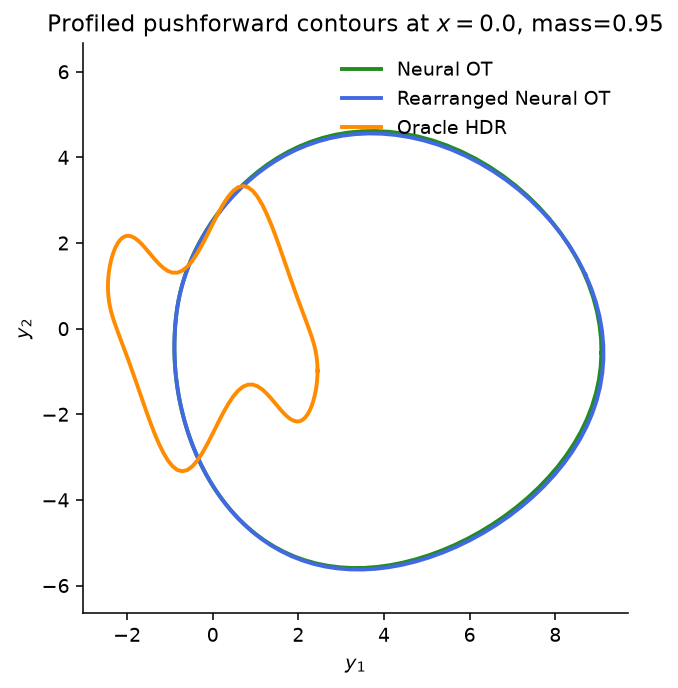

Saved plot to /Users/vladimir.kondratyev/minimal_volume_conformal_prediction/notebooks/profiling/profiling_outputs/figure_1_neural_ot_rearranged_sinusoidal_profiled.pdf


In [11]:
with cuda_memory_section("evaluation_and_sampling_contours"):
    plotting_coverage_mass = coverage_mass
    r_source = float(np.sqrt(chi2.ppf(plotting_coverage_mass, df=dataset.y_dim)))
    source_ball_boundary = circle_boundary(radius=r_source, n_points=n_boundary_points)

    neural_ot_contour = model_pushforward_contour(predictor, source_ball_boundary)
    rearranged_contour = model_pushforward_contour(rearranged_predictor, source_ball_boundary)
    oracle_hdr_contour = oracle_pushforward_contour(source_ball_boundary)

xmin, xmax, ymin, ymax = contour_bounds([
    neural_ot_contour,
    rearranged_contour,
    oracle_hdr_contour,
])

print(f"coverage_mass = {plotting_coverage_mass:.3f}")
print(f"x = {x_plot_value:.3f}")
print(f"source radius = {r_source:.4f}")

fig, ax = plt.subplots(figsize=(5.8, 4.8), constrained_layout=True)
ax.plot(neural_ot_contour[:, 0], neural_ot_contour[:, 1], color="forestgreen", linewidth=2.0, label="Neural OT")
ax.plot(rearranged_contour[:, 0], rearranged_contour[:, 1], color="royalblue", linewidth=2.0, label="Rearranged Neural OT")
ax.plot(oracle_hdr_contour[:, 0], oracle_hdr_contour[:, 1], color="darkorange", linewidth=2.0, label="Oracle HDR")
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$y_1$")
ax.set_ylabel(r"$y_2$")
ax.set_title(rf"Profiled pushforward contours at $x={x_plot_value:.1f}$, mass={coverage_mass:.2f}")
ax.legend(frameon=False, loc="upper right")
fig.savefig(output_path, format="pdf", bbox_inches="tight", pad_inches=0.02, metadata={"Creator": "Matplotlib"})
plt.show()
print(f"Saved plot to {output_path}")


## Profiling summary

This summary is computed from the measured CUDA sections and profiler events. When CUDA is unavailable, it records that the CUDA-specific measurements must be produced on a CUDA machine.


In [12]:
def _record_with_max(field: str):
    valid = [record for record in PROFILING_RECORDS if record.get(field) is not None]
    if not valid:
        return None
    return max(valid, key=lambda record: abs(float(record[field])))


highest_peak_record = _record_with_max("temporary_peak_delta_mib")
largest_persistent_record = _record_with_max("persistent_delta_mib")

print("CUDA profiling summary")
print("======================")
if not PROFILE_CUDA:
    print("CUDA was unavailable or CUDA_PROFILING_ENABLED=False in this run.")
    print("The notebook instrumentation is active and will report CUDA measurements on a CUDA machine.")
else:
    if highest_peak_record is not None:
        print(
            "Highest temporary peak allocated memory: "
            f"{highest_peak_record['label']} "
            f"({highest_peak_record['temporary_peak_delta_mib']:.2f} MiB over section start)."
        )
    if largest_persistent_record is not None:
        print(
            "Largest persistent allocated-memory increase: "
            f"{largest_persistent_record['label']} "
            f"({largest_persistent_record['persistent_delta_mib']:.2f} MiB)."
        )

    if PROFILER_TOP_CUDA_MEMORY_OPS:
        print("Top profiler ops by self CUDA memory usage:")
        for name, memory_mib in PROFILER_TOP_CUDA_MEMORY_OPS[:10]:
            print(f"  - {name}: {memory_mib:.2f} MiB")
    else:
        print("No positive self CUDA memory events were collected from the profiler.")

    if PROFILER_TOP_CUDA_TIME_OPS:
        print("Top profiler ops by self CUDA time:")
        for name, time_ms in PROFILER_TOP_CUDA_TIME_OPS[:10]:
            print(f"  - {name}: {time_ms:.2f} ms")

    if MEMORY_GROWTH_ALLOCATED_MIB:
        growth = MEMORY_GROWTH_ALLOCATED_MIB[-1] - MEMORY_GROWTH_ALLOCATED_MIB[0]
        monotone = all(
            later >= earlier - 1e-3
            for earlier, later in zip(MEMORY_GROWTH_ALLOCATED_MIB, MEMORY_GROWTH_ALLOCATED_MIB[1:])
        )
        print(
            "Allocated memory across repeated rearranged iterations: "
            f"{[round(value, 2) for value in MEMORY_GROWTH_ALLOCATED_MIB]} MiB"
        )
        print(f"Memory growth across iterations: {growth:.2f} MiB; monotone={monotone}.")
    else:
        print("Memory-growth check did not produce CUDA measurements.")

print("\nRetention checks")
for note in RETENTION_NOTES:
    print(f"- {note}")

print("\nLikely bottlenecks to inspect in the CUDA run")
print("- hessian_computation: Neural OT log_det builds Hessian rows with autograd.")
print("- ode_integration: RK4 calls the rearrangement vector field repeatedly.")
print("- jacobian_computation: standard dense skew field uses exact Jacobian work; compare with vector_field_implementation='experimental'.")
print("- c_transform_inverse: Neural OT training uses an inner LBFGS solve.")
print("- data_transfer_to_model_device: CPU dataloader batches can add transfer memory and time overhead.")

print("\nConcrete memory-reduction recommendations")
print("- Compare standard vs experimental rearrangement vector fields with the same profiler notebook.")
print("- Reduce rearrangement_ode_steps during training, then evaluate with more steps.")
print("- Use larger batches only after checking temporary peak memory in rearranged_representative_training_step.")
print("- Keep losses and outputs detached before storing them in notebook variables or lists.")
print("- Prefer JVP/VJP/trace estimators over full Jacobians where exact dense Jacobians are not required.")
print(f"\nTrace path: {trace_path}")
if DETAILED_MEMORY_HISTORY_ENABLED:
    print(f"Detailed memory snapshot path: {memory_snapshot_path}")


CUDA profiling summary
CUDA was unavailable or CUDA_PROFILING_ENABLED=False in this run.
The notebook instrumentation is active and will report CUDA measurements on a CUDA machine.

Retention checks
- No obvious live graph-attached tensor variables found in the notebook namespace.
- Python lists containing tensors:
-   - profile_batch_cpu: tensors=2, graph_attached=0
- Notebook representative steps use optimizer.zero_grad(set_to_none=True).
- No notebook code uses retain_graph=True.
- The main intentional high-memory autodiff regions are c_transform_inverse, hessian_computation, jacobian_computation, and ode_integration.

Likely bottlenecks to inspect in the CUDA run
- hessian_computation: Neural OT log_det builds Hessian rows with autograd.
- ode_integration: RK4 calls the rearrangement vector field repeatedly.
- jacobian_computation: standard dense skew field uses exact Jacobian work; compare with vector_field_implementation='experimental'.
- c_transform_inverse: Neural OT training u